In [ ]:
# Import delle librerie necessarie
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

# Silenziare i warning
warnings.filterwarnings('ignore')

SEED=2024

In [ ]:
# Caricamento del dataset Breast Cancer Wisconsin
data = load_breast_cancer()
X = data.data
y = data.target

# Split del dataset in set di addestramento e di test
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [ ]:
# Creazione e addestramento del modello MLP con un hidden layer di dimensione 100
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=SEED)
mlp_model.fit(xtrain, ytrain)

MLPClassifier(max_iter=1000, random_state=2024)

In [ ]:
# Calcolo e stampa delle accuratezze in-sample (addestramento) e out-of-sample (test)
train_accuracy = accuracy_score(ytrain, mlp_model.predict(xtrain))
test_accuracy = accuracy_score(ytest, mlp_model.predict(xtest))
print(f"Accuratezza in addestramento: {train_accuracy}")
print(f"Accuratezza in test: {test_accuracy}")

Accuratezza in addestramento: 0.9186813186813186
Accuratezza in test: 0.8947368421052632


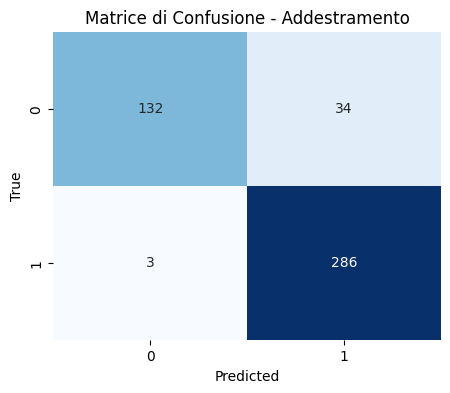

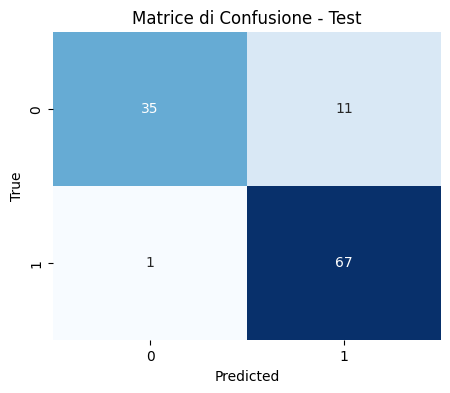

In [ ]:
# Funzione per visualizzare la matrice di confusione
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)

# Calcolo delle matrici di confusione per il set di addestramento e di test
cm_train = confusion_matrix(ytrain, mlp_model.predict(xtrain))
cm_test = confusion_matrix(ytest, mlp_model.predict(xtest))

# Visualizzazione delle matrici di confusione
plot_confusion_matrix(cm_train, 'Matrice di Confusione - Addestramento')
plot_confusion_matrix(cm_test, 'Matrice di Confusione - Test')

In [ ]:
#I coefficienti qui non ci sono d'aiuto..
print(mlp_model.coefs_[0].shape)
print(mlp_model.coefs_[1].shape)

weights = mlp.coefs_
biases = mlp.intercepts_

# Stampa i pesi e i bias
for i, (w, b) in enumerate(zip(weights, biases)):
    print(f"Layer {i + 1}")
    print(f"Weights:\n{w}")
    print(f"Biases:\n{b}")

(30, 100)
(100, 1)
Layer 1
Weights:
[[-4.07603797e-06  1.19117150e+00  7.96199259e-01  5.41272186e-01
  -3.48880274e-02]
 [-3.48996618e-02 -6.42452609e-01  7.08346957e-01  7.86198938e-01
   1.37670407e-03]
 [-1.31084225e-01  8.33204648e-01  5.59160908e-01 -1.14877314e+00
  -2.36764747e-02]
 [-2.30706214e-02 -6.38941630e-01 -2.68653339e-01 -9.36887799e-01
  -1.41628833e-03]]
Biases:
[ 0.18265501 -0.06413026  0.13719391  0.32327367 -0.07173742]
Layer 2
Weights:
[[ 2.57300241e-02 -3.32491359e-02]
 [-7.00933992e-23  5.12145986e-01]
 [-1.64268186e-01  4.36667913e-01]
 [-5.07662247e-02 -1.78473807e+00]
 [ 1.59054283e-01  1.78055098e-01]]
Biases:
[0.57104093 0.01367837]
Layer 3
Weights:
[[-1.90242882e-01  5.17191328e-03 -4.71975198e-10]
 [-1.31811558e+00 -4.40844774e-01 -4.85797578e-01]]
Biases:
[ 1.46666574 -0.71033837 -0.17594311]
